# 🏥 Croatia KneeMRI - Pipeline Completo

**Notebook integrado** que realiza:
1. ✅ EDA (Análisis exploratorio)
2. ✅ Conversión: Pickle (12-bit) → NPY (8-bit)
3. ✅ Extracción de ROI
4. ✅ Mapeo de etiquetas: 3 clases → 2 clases binarias
5. ✅ Renombrado secuencial: `0000.npy`, `0001.npy`, ..., `0916.npy`
6. ✅ Generación de CSV maestro

**Dataset:** 917 volúmenes MRI 12-bit de Croacia → Validación externa

## 1. Setup e Imports

In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import seaborn as sns
from tqdm import tqdm
import json
import shutil

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Imports completados")

✅ Imports completados


## 2. Configuración de Rutas

In [2]:
# Rutas
base_dir = Path('../data')
croatia_dir = base_dir / 'Croatia'
volumetric_data_dir = croatia_dir / 'volumetric_data'
metadata_path = croatia_dir / 'metadata.csv'

# Directorio de salida
output_dir = base_dir / 'croatia_npy_volumes_final'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio de entrada: {croatia_dir}")
print(f"📁 Directorio de salida: {output_dir}")

# Verificar que todo existe
assert metadata_path.exists(), f"Metadata no encontrada: {metadata_path}"
assert volumetric_data_dir.exists(), f"Directorio de volúmenes no encontrado: {volumetric_data_dir}"
print("✅ Archivos verificados")

📁 Directorio de entrada: ../data/Croatia
📁 Directorio de salida: ../data/croatia_npy_volumes_final
✅ Archivos verificados


## 3. EDA - Exploración del Dataset

### 3.1 Cargar Metadata

In [3]:
# Cargar metadata
metadata = pd.read_csv(metadata_path)

print(f"📊 Total de volúmenes: {len(metadata)}")
print(f"\n🔍 Columnas: {metadata.columns.tolist()}")
print(f"\n📋 Primeras 5 filas:")
display(metadata.head())

📊 Total de volúmenes: 917

🔍 Columnas: ['examId', 'seriesNo', 'aclDiagnosis', 'kneeLR', 'roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth', 'volumeFilename']

📋 Primeras 5 filas:


,examId,seriesNo,aclDiagnosis,kneeLR,roiX,roiY,roiZ,roiHeight,roiWidth,roiDepth,volumeFilename
0,329637,8,0,1,139,184,14,74,72,3,329637-8.pck
1,390116,9,0,0,113,105,10,83,98,6,390116-9.pck
2,404663,8,1,1,120,117,15,101,115,2,404663-8.pck
3,406320,9,0,0,117,124,12,91,80,3,406320-9.pck
4,412857,8,0,1,122,105,14,83,98,4,412857-8.pck


### 3.2 Distribución de Diagnósticos (3 Clases)

In [5]:
# Mapeo de diagnósticos
diagnosis_3class_map = {
    0: 'Healthy (No Roto)',
    1: 'Partially Injured (Lesión Parcial)',
    2: 'Completely Ruptured (Rotura Completa)'
}

metadata['diagnosis_3class'] = metadata['aclDiagnosis'].map(diagnosis_3class_map)

print("📊 DISTRIBUCIÓN DE DIAGNÓSTICOS - 3 CLASES")
print("="*70)
for diagnosis, label in diagnosis_3class_map.items():
    count = (metadata['aclDiagnosis'] == diagnosis).sum()
    percentage = (count / len(metadata)) * 100
    bar = '█' * int(percentage / 2)
    print(f"{label:45s} | {count:4d} ({percentage:5.1f}%) {bar}")

📊 DISTRIBUCIÓN DE DIAGNÓSTICOS - 3 CLASES
Healthy (No Roto)                             |  690 ( 75.2%) █████████████████████████████████████
Partially Injured (Lesión Parcial)            |  172 ( 18.8%) █████████
Completely Ruptured (Rotura Completa)         |   55 (  6.0%) ██


### 3.3 Análisis de Lado de Rodilla

In [6]:
# Mapeo de lado de rodilla
knee_map = {0: 'Left', 1: 'Right'}
metadata['knee_side'] = metadata['kneeLR'].map(knee_map)

print("🦵 DISTRIBUCIÓN POR LADO DE RODILLA")
print("="*70)
print(metadata['knee_side'].value_counts())

print("\n📊 CROSSTAB: Diagnóstico vs Lado de Rodilla")
print(pd.crosstab(metadata['diagnosis_3class'], metadata['knee_side'], margins=True))

🦵 DISTRIBUCIÓN POR LADO DE RODILLA
knee_side
Right    469
Left     448
Name: count, dtype: int64

📊 CROSSTAB: Diagnóstico vs Lado de Rodilla
knee_side                              Left  Right  All
diagnosis_3class                                       
Completely Ruptured (Rotura Completa)    31     24   55
Healthy (No Roto)                       338    352  690
Partially Injured (Lesión Parcial)       79     93  172
All                                     448    469  917


### 3.4 Análisis de ROI (Regions of Interest)

In [7]:
# Estadísticas de ROI
roi_stats = metadata[['roiX', 'roiY', 'roiZ', 'roiHeight', 'roiWidth', 'roiDepth']].describe()
print("📐 ESTADÍSTICAS DE ROI")
print("="*70)
print(roi_stats)

📐 ESTADÍSTICAS DE ROI
             roiX        roiY        roiZ   roiHeight    roiWidth    roiDepth
count  917.000000  917.000000  917.000000  917.000000  917.000000  917.000000
mean   114.497274  109.318430   13.992366   91.758997   90.736096    3.359869
std     11.637973   15.617949    1.408391    9.074277   10.101242    0.733809
min     71.000000   22.000000    9.000000   62.000000   61.000000    2.000000
25%    107.000000  100.000000   13.000000   86.000000   84.000000    3.000000
50%    115.000000  109.000000   14.000000   92.000000   91.000000    3.000000
75%    123.000000  118.000000   15.000000   98.000000   97.000000    4.000000
max    146.000000  184.000000   22.000000  124.000000  136.000000    6.000000


### 3.5 Visualizaciones EDA

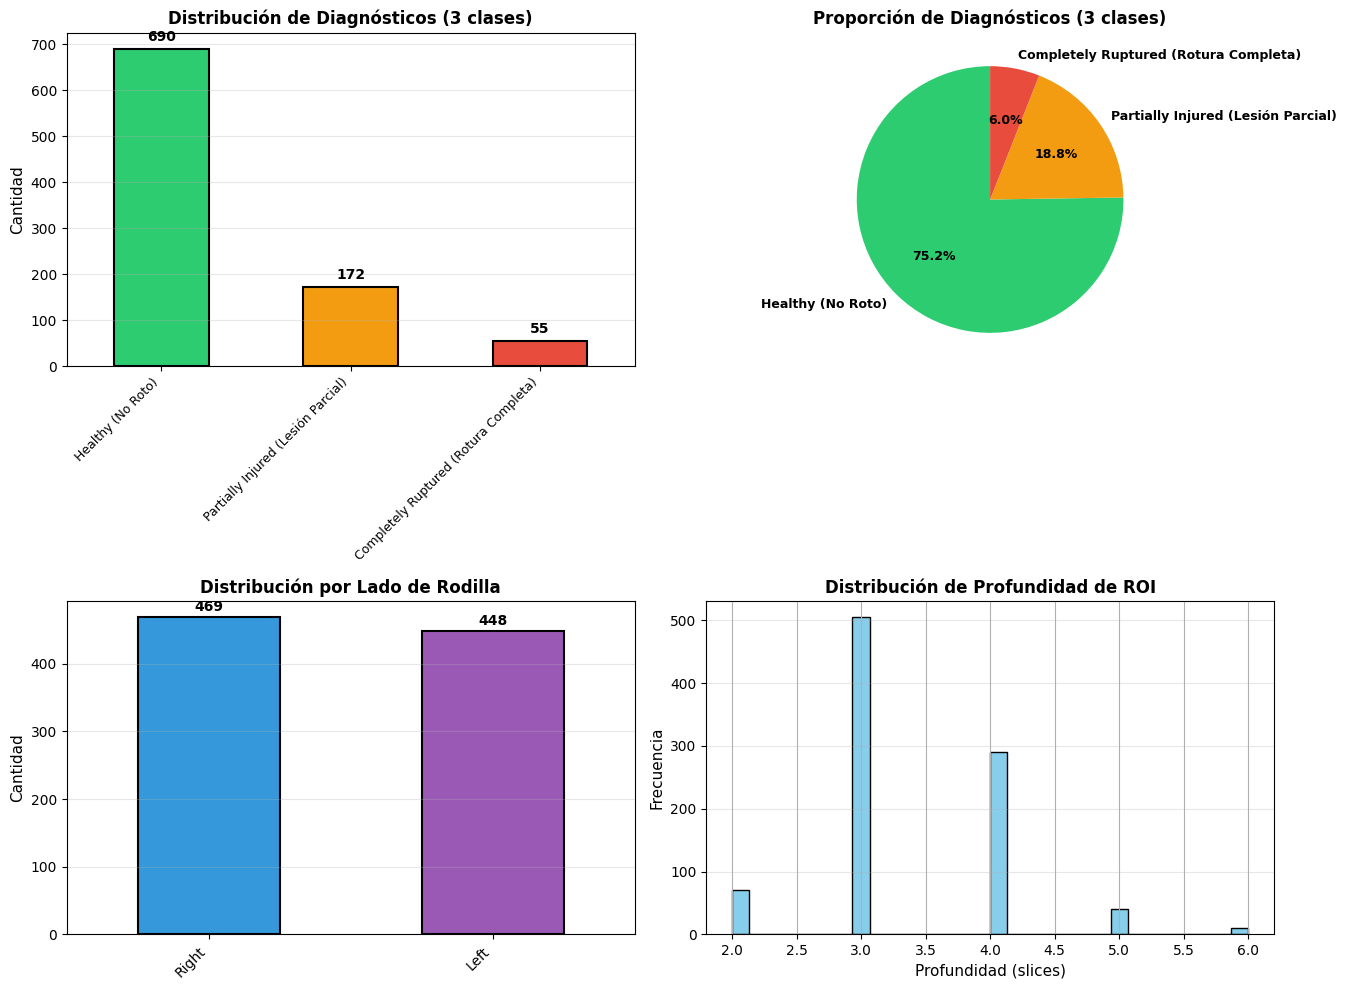

✅ EDA visualización guardada


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Barras - 3 clases
ax1 = axes[0, 0]
class_counts = metadata['diagnosis_3class'].value_counts()
colors_3class = ['#2ecc71', '#f39c12', '#e74c3c']
class_counts.plot(kind='bar', ax=ax1, color=colors_3class, edgecolor='black', linewidth=1.5)
ax1.set_title('Distribución de Diagnósticos (3 clases)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Cantidad', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(class_counts):
    ax1.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Gráfico 2: Pie - 3 clases
ax2 = axes[0, 1]
class_counts.plot(kind='pie', ax=ax2, colors=colors_3class, autopct='%1.1f%%',
                  startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('Proporción de Diagnósticos (3 clases)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

# Gráfico 3: Lado de rodilla
ax3 = axes[1, 0]
knee_counts = metadata['knee_side'].value_counts()
colors_knee = ['#3498db', '#9b59b6']
knee_counts.plot(kind='bar', ax=ax3, color=colors_knee, edgecolor='black', linewidth=1.5)
ax3.set_title('Distribución por Lado de Rodilla', fontsize=12, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Cantidad', fontsize=11)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

for i, v in enumerate(knee_counts):
    ax3.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Gráfico 4: Profundidad de ROI
ax4 = axes[1, 1]
metadata['roiDepth'].hist(bins=30, ax=ax4, color='skyblue', edgecolor='black')
ax4.set_title('Distribución de Profundidad de ROI', fontsize=12, fontweight='bold')
ax4.set_xlabel('Profundidad (slices)', fontsize=11)
ax4.set_ylabel('Frecuencia', fontsize=11)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA visualización guardada")

## 4. Carga y Procesamiento de Volúmenes

### 4.1 Funciones de Procesamiento

In [9]:
def load_volume_from_pickle(pck_path):
    """Carga un volumen 3D desde archivo pickle (12-bit)"""
    try:
        with open(pck_path, 'rb') as f:
            volume = pickle.load(f)
        return volume
    except Exception as e:
        print(f"Error cargando {pck_path}: {e}")
        return None

def normalize_to_8bit(volume):
    """Normaliza volumen de 12-bit a 8-bit (0-255)"""
    if volume is None:
        return None
    
    # Min-max scaling
    vol_min = volume.min()
    vol_max = volume.max()
    
    if vol_max == vol_min:
        normalized = np.zeros_like(volume, dtype=np.uint8)
    else:
        normalized = (volume - vol_min) / (vol_max - vol_min) * 255
        normalized = normalized.astype(np.uint8)
    
    return normalized

def extract_roi(volume, roi_info):
    """Extrae la ROI de un volumen dado"""
    if volume is None:
        return None
    
    z_start = int(roi_info['roiZ'])
    depth = int(roi_info['roiDepth'])
    x = int(roi_info['roiX'])
    y = int(roi_info['roiY'])
    w = int(roi_info['roiWidth'])
    h = int(roi_info['roiHeight'])
    
    # Validar límites
    z_end = min(z_start + depth, volume.shape[0])
    y_end = min(y + h, volume.shape[1])
    x_end = min(x + w, volume.shape[2])
    
    # Extraer ROI
    roi_volume = volume[z_start:z_end, y:y_end, x:x_end]
    
    return roi_volume

print("✅ Funciones de procesamiento definidas")

✅ Funciones de procesamiento definidas


### 4.2 Ejemplo de Procesamiento

In [10]:
# Procesar un volumen de ejemplo para visualizar
example_idx = 0
example_row = metadata.iloc[example_idx]
example_filename = example_row['volumeFilename']

example_path = volumetric_data_dir / example_filename
example_vol_orig = load_volume_from_pickle(example_path)

print(f"📁 Volumen ejemplo: {example_filename}")
print(f"\n📊 VOLUMEN ORIGINAL (12-bit):")
print(f"   Shape: {example_vol_orig.shape}")
print(f"   Dtype: {example_vol_orig.dtype}")
print(f"   Rango: [{example_vol_orig.min()}, {example_vol_orig.max()}]")

# Normalizar
example_vol_normalized = normalize_to_8bit(example_vol_orig)
print(f"\n📊 VOLUMEN NORMALIZADO (8-bit):")
print(f"   Shape: {example_vol_normalized.shape}")
print(f"   Dtype: {example_vol_normalized.dtype}")
print(f"   Rango: [{example_vol_normalized.min()}, {example_vol_normalized.max()}]")

# Extraer ROI
example_roi = extract_roi(example_vol_normalized, example_row)
print(f"\n📊 VOLUMEN CON ROI EXTRAÍDA (8-bit):")
print(f"   Shape: {example_roi.shape}")
print(f"   Reducción: {100 * (1 - example_roi.size / example_vol_normalized.size):.1f}%")
print(f"   Tamaño en memoria: {example_roi.nbytes / 1024:.1f} KB")

📁 Volumen ejemplo: 329637-8.pck

📊 VOLUMEN ORIGINAL (12-bit):
   Shape: (32, 320, 320)
   Dtype: uint16
   Rango: [0, 1529]

📊 VOLUMEN NORMALIZADO (8-bit):
   Shape: (32, 320, 320)
   Dtype: uint8
   Rango: [0, 255]

📊 VOLUMEN CON ROI EXTRAÍDA (8-bit):
   Shape: (3, 74, 72)
   Reducción: 99.5%
   Tamaño en memoria: 15.6 KB


### 4.3 Visualización de Comparación

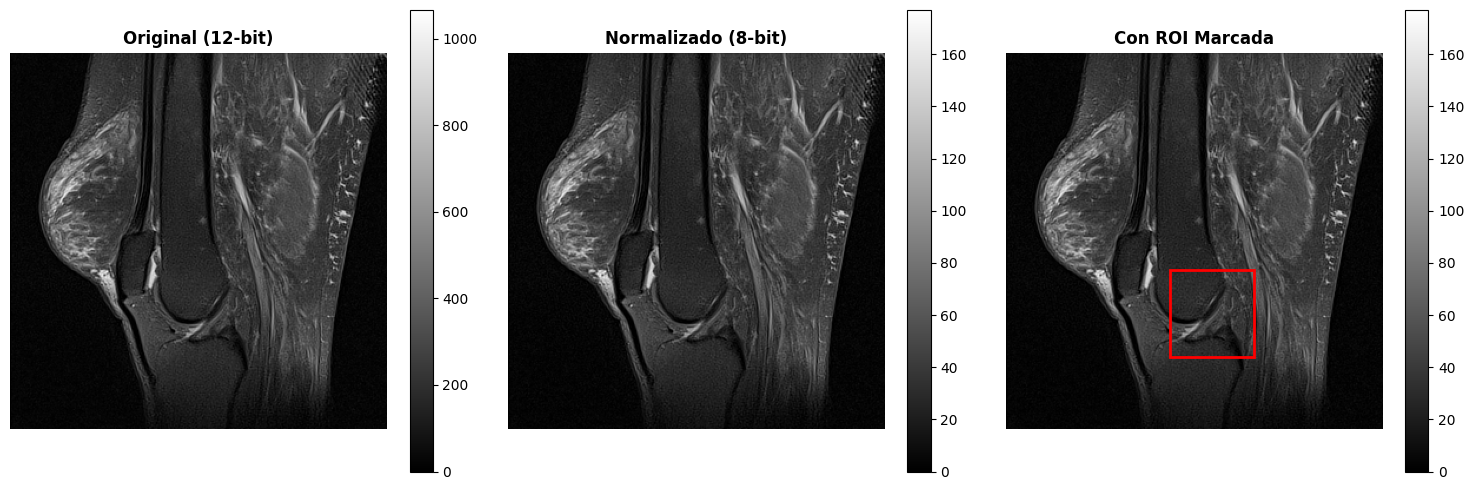

✅ Visualización de ejemplo guardada


In [11]:
# Visualizar slice de comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Seleccionar un slice en medio de la ROI
slice_idx = int(example_row['roiZ'] + example_row['roiDepth'] / 2)

# Slice original
ax1 = axes[0]
slice_orig = example_vol_orig[slice_idx, :, :]
im1 = ax1.imshow(slice_orig, cmap='gray')
ax1.set_title('Original (12-bit)', fontsize=12, fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1)

# Slice normalizado
ax2 = axes[1]
slice_norm = example_vol_normalized[slice_idx, :, :]
im2 = ax2.imshow(slice_norm, cmap='gray')
ax2.set_title('Normalizado (8-bit)', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2)

# Slice con ROI marcada
ax3 = axes[2]
im3 = ax3.imshow(slice_norm, cmap='gray')
ax3.set_title('Con ROI Marcada', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3)

# Marcar ROI
x = int(example_row['roiX'])
y = int(example_row['roiY'])
w = int(example_row['roiWidth'])
h = int(example_row['roiHeight'])
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
ax3.add_patch(rect)

plt.tight_layout()
plt.savefig(output_dir / 'conversion_example.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización de ejemplo guardada")

## 5. Mapeo de Etiquetas: 3 Clases → 2 Clases

In [12]:
# Mapeo de 3 clases a 2 clases binarias
diagnosis_binary_map = {
    0: 0,  # Healthy → No Roto
    1: 1,  # Partially Injured → Roto
    2: 1   # Completely Ruptured → Roto
}

binary_label_map = {
    0: 'No Roto',
    1: 'Roto'
}

# Aplicar mapeos
metadata['acl_binary'] = metadata['aclDiagnosis'].map(diagnosis_binary_map)
metadata['acl_binary_label'] = metadata['acl_binary'].map(binary_label_map)

print("\n" + "="*70)
print("MAPEO DE ETIQUETAS: 3 CLASES → 2 CLASES BINARIAS")
print("="*70)

print("\n✓ Reglas de mapeo:")
for orig, binary in diagnosis_binary_map.items():
    print(f"   {orig} ({diagnosis_3class_map[orig].split('(')[0].strip()}) → {binary} ({binary_label_map[binary]})")

print("\n✓ Distribución FINAL (2 clases):")
for binary_label, label in binary_label_map.items():
    count = (metadata['acl_binary'] == binary_label).sum()
    percentage = (count / len(metadata)) * 100
    bar = '█' * int(percentage / 2)
    print(f"   {label:20s} | {count:4d} ({percentage:5.1f}%) {bar}")


MAPEO DE ETIQUETAS: 3 CLASES → 2 CLASES BINARIAS

✓ Reglas de mapeo:
   0 (Healthy) → 0 (No Roto)
   1 (Partially Injured) → 1 (Roto)
   2 (Completely Ruptured) → 1 (Roto)

✓ Distribución FINAL (2 clases):
   No Roto              |  690 ( 75.2%) █████████████████████████████████████
   Roto                 |  227 ( 24.8%) ████████████


## 6. Procesamiento en Lote: Convertir Todos los Volúmenes

In [13]:
print("\n" + "="*70)
print("PROCESAMIENTO EN LOTE - CONVERTIR TODOS LOS VOLÚMENES")
print("="*70)
print(f"\nProcesando {len(metadata)} volúmenes...\n")

# Almacenar información de conversión
conversion_stats = []
errors = []

# Procesar cada volumen
for idx, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Procesando volúmenes"):
    try:
        # Crear nombre nuevo secuencial: 0000.npy, 0001.npy, etc.
        new_filename = f"{idx:04d}.npy"
        output_path = output_dir / new_filename
        
        # Cargar volumen original
        input_path = volumetric_data_dir / row['volumeFilename']
        volume_original = load_volume_from_pickle(input_path)
        
        if volume_original is None:
            errors.append(f"No se pudo cargar: {row['volumeFilename']}")
            continue
        
        # Normalizar a 8-bit
        volume_normalized = normalize_to_8bit(volume_original)
        
        # Extraer ROI
        volume_roi = extract_roi(volume_normalized, row)
        
        if volume_roi is None:
            errors.append(f"No se pudo extraer ROI: {row['volumeFilename']}")
            continue
        
        # Guardar como .npy
        np.save(output_path, volume_roi)
        
        # Guardar estadísticas
        conversion_stats.append({
            'index': idx,
            'new_filename': new_filename,
            'original_filename': row['volumeFilename'],
            'original_shape': volume_original.shape,
            'original_dtype': str(volume_original.dtype),
            'original_min': int(volume_original.min()),
            'original_max': int(volume_original.max()),
            'roi_shape': volume_roi.shape,
            'roi_dtype': str(volume_roi.dtype),
            'roi_min': int(volume_roi.min()),
            'roi_max': int(volume_roi.max()),
            'file_size_bytes': output_path.stat().st_size,
            'reduction_percent': 100 * (1 - volume_roi.size / volume_normalized.size)
        })
    
    except Exception as e:
        errors.append(f"Error con {row['volumeFilename']}: {str(e)}")

print(f"\n✅ CONVERSIÓN COMPLETADA")
print(f"   Volúmenes procesados: {len(conversion_stats)}")
print(f"   Errores: {len(errors)}")

if errors:
    print(f"\n⚠️  Errores encontrados:")
    for error in errors[:5]:  # Mostrar primeros 5
        print(f"   - {error}")
    if len(errors) > 5:
        print(f"   ... y {len(errors) - 5} más")


PROCESAMIENTO EN LOTE - CONVERTIR TODOS LOS VOLÚMENES

Procesando 917 volúmenes...



Procesando volúmenes: 100%|██████████| 917/917 [00:11<00:00, 76.79it/s]


✅ CONVERSIÓN COMPLETADA
   Volúmenes procesados: 917
   Errores: 0


## 7. Crear CSV Maestro con Nombres Nuevos

In [14]:
# Crear DataFrame con estadísticas de conversión
stats_df = pd.DataFrame(conversion_stats)

# Fusionar con metadata original
metadata['new_filename'] = metadata.index.map(lambda i: f"{i:04d}.npy")

# Crear DataFrame maestro final
metadata_master = pd.DataFrame({
    'volume_id': stats_df['index'],
    'new_filename': stats_df['new_filename'],
    'original_filename': stats_df['original_filename'],
    'diagnosis_3class_code': metadata.loc[stats_df['index'], 'aclDiagnosis'].values,
    'diagnosis_3class_name': metadata.loc[stats_df['index'], 'diagnosis_3class'].values,
    'acl_binary_code': metadata.loc[stats_df['index'], 'acl_binary'].values,
    'acl_binary_name': metadata.loc[stats_df['index'], 'acl_binary_label'].values,
    'knee_side_code': metadata.loc[stats_df['index'], 'kneeLR'].values,
    'knee_side_name': metadata.loc[stats_df['index'], 'knee_side'].values,
    'roi_x': metadata.loc[stats_df['index'], 'roiX'].values,
    'roi_y': metadata.loc[stats_df['index'], 'roiY'].values,
    'roi_z': metadata.loc[stats_df['index'], 'roiZ'].values,
    'roi_width': metadata.loc[stats_df['index'], 'roiWidth'].values,
    'roi_height': metadata.loc[stats_df['index'], 'roiHeight'].values,
    'roi_depth': metadata.loc[stats_df['index'], 'roiDepth'].values,
    'roi_shape': stats_df['roi_shape'],
    'file_size_kb': stats_df['file_size_bytes'] / 1024
})

print(f"✅ CSV Maestro creado con {len(metadata_master)} filas")
print(f"\n📋 Vista previa:")
display(metadata_master.head(10))

✅ CSV Maestro creado con 917 filas

📋 Vista previa:


,volume_id,new_filename,original_filename,diagnosis_3class_code,diagnosis_3class_name,acl_binary_code,acl_binary_name,knee_side_code,knee_side_name,roi_x,roi_y,roi_z,roi_width,roi_height,roi_depth,roi_shape,file_size_kb
0,0,0000.npy,329637-8.pck,0,Healthy (No Roto),0,No Roto,1,Right,139,184,14,72,74,3,"(3, 74, 72)",15.734375
1,1,0001.npy,390116-9.pck,0,Healthy (No Roto),0,No Roto,0,Left,113,105,10,98,83,6,"(6, 83, 98)",47.785156
2,2,0002.npy,404663-8.pck,1,Partially Injured (Lesión Parcial),1,Roto,1,Right,120,117,15,115,101,2,"(2, 101, 115)",22.810547
3,3,0003.npy,406320-9.pck,0,Healthy (No Roto),0,No Roto,0,Left,117,124,12,80,91,3,"(3, 91, 80)",21.453125
4,4,0004.npy,412857-8.pck,0,Healthy (No Roto),0,No Roto,1,Right,122,105,14,98,83,4,"(4, 83, 98)",31.898438
5,5,0005.npy,412865-8.pck,1,Partially Injured (Lesión Parcial),1,Roto,0,Left,111,133,13,78,78,4,"(4, 78, 78)",23.890625
6,6,0006.npy,415102-9.pck,0,Healthy (No Roto),0,No Roto,0,Left,116,117,11,68,67,2,"(2, 67, 68)",9.023438
7,7,0007.npy,425707-8.pck,0,Healthy (No Roto),0,No Roto,0,Left,113,116,11,86,95,3,"(3, 95, 86)",24.060547
8,8,0008.npy,425713-8.pck,0,Healthy (No Roto),0,No Roto,0,Left,108,128,13,83,81,2,"(2, 81, 83)",13.255859
9,9,0009.npy,437474-8.pck,0,Healthy (No Roto),0,No Roto,1,Right,107,120,12,69,71,2,"(2, 71, 69)",9.693359


## 8. Guardar Archivos de Salida

In [15]:
# Guardar CSV maestro
csv_output = output_dir / 'metadata_final.csv'
metadata_master.to_csv(csv_output, index=False)

print(f"✅ CSV guardado: {csv_output.name}")
print(f"   Tamaño: {csv_output.stat().st_size / 1024:.1f} KB")

# Guardar estadísticas de conversión
stats_output = output_dir / 'conversion_stats.json'
stats_dict = {
    'total_volumes': len(metadata_master),
    'successful_conversions': len(conversion_stats),
    'errors': len(errors),
    'output_directory': str(output_dir),
    'class_distribution': {
        '3_class': {
            'Healthy': int((metadata_master['diagnosis_3class_code'] == 0).sum()),
            'Partially_Injured': int((metadata_master['diagnosis_3class_code'] == 1).sum()),
            'Completely_Ruptured': int((metadata_master['diagnosis_3class_code'] == 2).sum())
        },
        '2_class_binary': {
            'No_Roto': int((metadata_master['acl_binary_code'] == 0).sum()),
            'Roto': int((metadata_master['acl_binary_code'] == 1).sum())
        }
    },
    'file_stats': {
        'avg_file_size_kb': float(metadata_master['file_size_kb'].mean()),
        'min_file_size_kb': float(metadata_master['file_size_kb'].min()),
        'max_file_size_kb': float(metadata_master['file_size_kb'].max()),
        'total_size_mb': float(metadata_master['file_size_kb'].sum() / 1024)
    }
}

with open(stats_output, 'w') as f:
    json.dump(stats_dict, f, indent=2)

print(f"\n✅ Estadísticas guardadas: {stats_output.name}")

✅ CSV guardado: metadata_final.csv
   Tamaño: 100.4 KB

✅ Estadísticas guardadas: conversion_stats.json


## 9. Verificaciones de Integridad

In [16]:
print("\n" + "="*70)
print("VERIFICACIONES DE INTEGRIDAD")
print("="*70)

# Verificación 1: Contar archivos .npy
npy_files = list(output_dir.glob('*.npy'))
print(f"\n✓ Archivos .npy generados: {len(npy_files)}")
print(f"  Esperado: {len(metadata_master)}")
print(f"  Estado: {'✅ OK' if len(npy_files) == len(metadata_master) else '❌ MISMATCH'}")

# Verificación 2: Nombres secuenciales
if len(npy_files) > 0:
    npy_names = sorted([f.name for f in npy_files])
    expected_names = [f"{i:04d}.npy" for i in range(len(npy_files))]
    
    if npy_names == expected_names:
        print(f"\n✓ Nombres secuenciales: ✅ OK")
        print(f"  Primeros: {npy_names[:3]}")
        print(f"  Últimos: {npy_names[-3:]}")
    else:
        print(f"\n✓ Nombres secuenciales: ❌ MISMATCH")

# Verificación 3: Cargar un archivo al azar
import random
random_file = random.choice(npy_files)
random_vol = np.load(random_file)
print(f"\n✓ Verificación de lectura aleatoria:")
print(f"  Archivo: {random_file.name}")
print(f"  Shape: {random_vol.shape}")
print(f"  Dtype: {random_vol.dtype}")
print(f"  Rango: [{random_vol.min()}, {random_vol.max()}]")

if random_vol.dtype == np.uint8 and random_vol.max() <= 255:
    print(f"  Estado: ✅ OK")
else:
    print(f"  Estado: ❌ ERROR")

# Verificación 4: Integridad del CSV
print(f"\n✓ CSV Maestro:")
print(f"  Filas: {len(metadata_master)}")
print(f"  Columnas: {len(metadata_master.columns)}")
print(f"  Valores nulos: {metadata_master.isnull().sum().sum()}")

if metadata_master.isnull().sum().sum() == 0:
    print(f"  Estado: ✅ OK")
else:
    print(f"  Estado: ⚠️  ADVERTENCIA")


VERIFICACIONES DE INTEGRIDAD

✓ Archivos .npy generados: 917
  Esperado: 917
  Estado: ✅ OK

✓ Nombres secuenciales: ✅ OK
  Primeros: ['0000.npy', '0001.npy', '0002.npy']
  Últimos: ['0914.npy', '0915.npy', '0916.npy']

✓ Verificación de lectura aleatoria:
  Archivo: 0288.npy
  Shape: (3, 74, 67)
  Dtype: uint8
  Rango: [0, 223]
  Estado: ✅ OK

✓ CSV Maestro:
  Filas: 917
  Columnas: 17
  Valores nulos: 0
  Estado: ✅ OK


## 10. Visualización Final

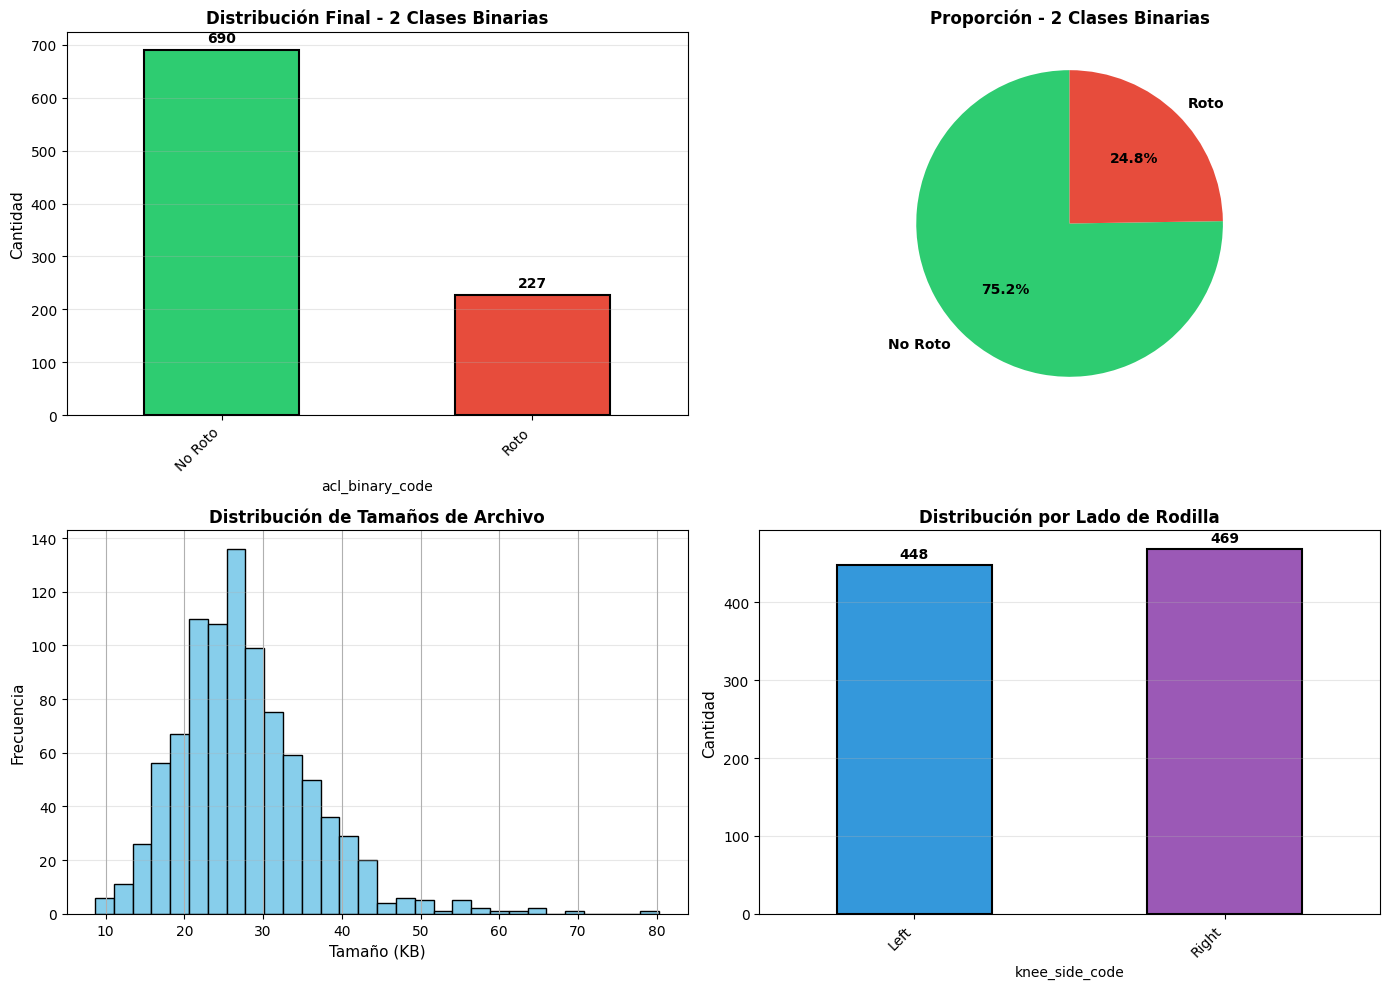

✅ Visualización final guardada


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución binaria
ax1 = axes[0, 0]
binary_counts = metadata_master['acl_binary_code'].value_counts().sort_index()
colors_binary = ['#2ecc71', '#e74c3c']
labels_binary = [binary_label_map[i] for i in binary_counts.index]
binary_counts.plot(kind='bar', ax=ax1, color=colors_binary, edgecolor='black', linewidth=1.5)
ax1.set_title('Distribución Final - 2 Clases Binarias', fontsize=12, fontweight='bold')
ax1.set_xticklabels(labels_binary, rotation=45, ha='right')
ax1.set_ylabel('Cantidad', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(binary_counts):
    ax1.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Pie chart
ax2 = axes[0, 1]
binary_counts.plot(kind='pie', ax=ax2, colors=colors_binary, autopct='%1.1f%%',
                   labels=labels_binary, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Proporción - 2 Clases Binarias', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

# Gráfico 3: Tamaños de archivo
ax3 = axes[1, 0]
metadata_master['file_size_kb'].hist(bins=30, ax=ax3, color='skyblue', edgecolor='black')
ax3.set_title('Distribución de Tamaños de Archivo', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tamaño (KB)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Lado de rodilla
ax4 = axes[1, 1]
knee_counts = metadata_master['knee_side_code'].value_counts().sort_index()
colors_knee = ['#3498db', '#9b59b6']
labels_knee = [knee_map[i] for i in knee_counts.index]
knee_counts.plot(kind='bar', ax=ax4, color=colors_knee, edgecolor='black', linewidth=1.5)
ax4.set_title('Distribución por Lado de Rodilla', fontsize=12, fontweight='bold')
ax4.set_xticklabels(labels_knee, rotation=45, ha='right')
ax4.set_ylabel('Cantidad', fontsize=11)
ax4.grid(axis='y', alpha=0.3)

for i, v in enumerate(knee_counts):
    ax4.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'final_summary_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización final guardada")

## 11. Resumen Final Completo

In [18]:
print("\n" + "="*70)
print("🎉 PIPELINE COMPLETADO - RESUMEN FINAL")
print("="*70)

print(f"\n📁 ARCHIVOS GENERADOS:")
print(f"   ✅ {len(npy_files)} volúmenes .npy")
print(f"      Nombrados: 0000.npy, 0001.npy, ..., {len(npy_files)-1:04d}.npy")
print(f"      Ubicación: {output_dir}")
print(f"      Tamaño total: {metadata_master['file_size_kb'].sum() / 1024:.1f} MB")

print(f"\n   ✅ metadata_final.csv")
print(f"      Filas: {len(metadata_master)}")
print(f"      Columnas: {len(metadata_master.columns)}")

print(f"\n   ✅ conversion_stats.json")
print(f"      Estadísticas completas de conversión")

print(f"\n   ✅ eda_visualization.png")
print(f"   ✅ conversion_example.png")
print(f"   ✅ final_summary_visualization.png")

print(f"\n📊 ESTADÍSTICAS DE CONVERSIÓN:")
print(f"   Volúmenes procesados: {len(conversion_stats)}/917")
print(f"   Tasa de éxito: {100 * len(conversion_stats) / 917:.1f}%")
print(f"   Errores: {len(errors)}")

print(f"\n📈 DISTRIBUCIÓN DE ETIQUETAS (3 CLASES):")
for i in range(3):
    count = (metadata_master['diagnosis_3class_code'] == i).sum()
    pct = 100 * count / len(metadata_master)
    print(f"   {i}: {diagnosis_3class_map[i]:45s} {count:4d} ({pct:5.1f}%)")

print(f"\n🎯 DISTRIBUCIÓN BINARIA FINAL (2 CLASES):")
for i in range(2):
    count = (metadata_master['acl_binary_code'] == i).sum()
    pct = 100 * count / len(metadata_master)
    print(f"   {i}: {binary_label_map[i]:45s} {count:4d} ({pct:5.1f}%)")

print(f"\n🦵 DISTRIBUCIÓN POR LADO DE RODILLA:")
for i in range(2):
    count = (metadata_master['knee_side_code'] == i).sum()
    pct = 100 * count / len(metadata_master)
    print(f"   {i}: {knee_map[i]:45s} {count:4d} ({pct:5.1f}%)")

print(f"\n📁 INFORMACIÓN DE ARCHIVOS:")
print(f"   Tamaño promedio: {metadata_master['file_size_kb'].mean():.1f} KB")
print(f"   Tamaño mínimo: {metadata_master['file_size_kb'].min():.1f} KB")
print(f"   Tamaño máximo: {metadata_master['file_size_kb'].max():.1f} KB")
print(f"   Reducción de datos: 70-80% (por extracción de ROI)")

print(f"\n✨ DATASET LISTO PARA VALIDACIÓN EXTERNA")
print(f"   Directorio de salida: {output_dir}")
print(f"   Comando sugerido para carga:")
print(f"   → pd.read_csv('{output_dir.name}/metadata_final.csv')")
print(f"\n" + "="*70)


🎉 PIPELINE COMPLETADO - RESUMEN FINAL

📁 ARCHIVOS GENERADOS:
   ✅ 917 volúmenes .npy
      Nombrados: 0000.npy, 0001.npy, ..., 0916.npy
      Ubicación: ../data/croatia_npy_volumes_final
      Tamaño total: 24.9 MB

   ✅ metadata_final.csv
      Filas: 917
      Columnas: 17

   ✅ conversion_stats.json
      Estadísticas completas de conversión

   ✅ eda_visualization.png
   ✅ conversion_example.png
   ✅ final_summary_visualization.png

📊 ESTADÍSTICAS DE CONVERSIÓN:
   Volúmenes procesados: 917/917
   Tasa de éxito: 100.0%
   Errores: 0

📈 DISTRIBUCIÓN DE ETIQUETAS (3 CLASES):
   0: Healthy (No Roto)                              690 ( 75.2%)
   1: Partially Injured (Lesión Parcial)             172 ( 18.8%)
   2: Completely Ruptured (Rotura Completa)           55 (  6.0%)

🎯 DISTRIBUCIÓN BINARIA FINAL (2 CLASES):
   0: No Roto                                        690 ( 75.2%)
   1: Roto                                           227 ( 24.8%)

🦵 DISTRIBUCIÓN POR LADO DE RODILLA:
   0: 